# Seminário: IA na Saúde — Equidade e Vieses
## Tópico 1: Acesso e Infraestrutura na Coleta e Aplicação de Dados (SUS vs. Saúde Suplementar)

**Apresentador(a):** Pessoa 1  
**Tempo Estimado:** 20 minutos  

---

### Mapeamento Lógico da Apresentação (Foco em Infraestrutura & Uso Real de IA):
1. **O Parque Tecnológico de Imagem (CNES/DATASUS):** Comparativo da densidade de equipamentos de alta tecnologia (Tomógrafos, Ressonâncias, Mamógrafos) por 100 mil habitantes no SUS vs. Privado.
2. **Gargalos de Conectividade e Digitalização na Atenção Básica (TIC Saúde):** A infraestrutura de rede, prontuário eletrônico e servidores nas UBSs que impedem a chegada de IA no SUS.
3. **Adoção e Uso Efetivo de Ferramentas de IA (TIC Saúde / Abrais):** Comparativo direto de onde as soluções de Inteligência Artificial já estão rodando na prática (Público vs. Privado).
4. **Desigualdade Regional e Concentração de Leitos/Tecnologia:** A dupla desigualdade (Setorial + Geográfica) na distribuição de leitos de UTI e alta complexidade.
5. **O Mismatch Estrutural de Dados:** Síntese em barra empilhada da disparidade entre população dependente e infraestrutura geradora de dados.
6. **Ponte para a Pessoa 2:** Transição conectando a escassez de infraestrutura à formação de bases de dados enviesadas.


Estes gráficos consolidam os indicadores mais recentes dos relatórios nacionais de saúde digital — principalmente a Pesquisa TIC Saúde do Cetic.br e o CNES/DATASUS pós-pandemia (base de referência 2022–2024). Eles retratam a fotografia atual do parque tecnológico e da maturidade digital do país.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo global padronizado
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Paleta de Cores Institucional
COR_SUS = '#254370'       
COR_PRIVADO = '#17947f'   
COR_ACENTO = '#00897b'    
COR_CINZA = '#78909c' 


---
## Bloco 1: O Parque Tecnológico e Equipamentos de Imagem
### Densidade de Equipamentos por 100 mil Habitantes (CNES/DATASUS)

**Por que este gráfico é fundamental?**
Exibe a infraestrutura física direta que gera imagens médicas (a principal matéria-prima para modelos de visão computacional em IA). Mostra a enorme disparidade de acesso entre o usuário do SUS e o usuário do setor privado.


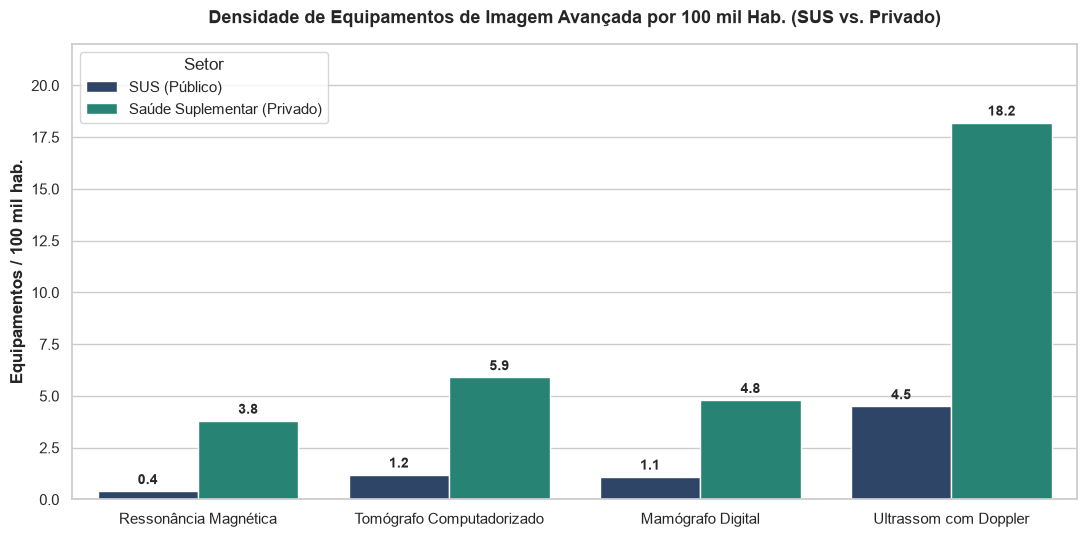

In [33]:
# Dados consolidados CNES/DATASUS (Equipamentos por 100 mil habitantes)
dados_equip = pd.DataFrame({
    'Equipamento': ['Ressonância Magnética', 'Tomógrafo Computadorizado', 'Mamógrafo Digital', 'Ultrassom com Doppler'],
    'SUS (Público)': [0.4, 1.2, 1.1, 4.5],
    'Saúde Suplementar (Privado)': [3.8, 5.9, 4.8, 18.2]
})

df_equip_melt = dados_equip.melt(id_vars='Equipamento', var_name='Setor', value_name='Por_100k')

plt.figure(figsize=(11, 5.5))
ax1 = sns.barplot(
    data=df_equip_melt, 
    x='Equipamento', 
    y='Por_100k', 
    hue='Setor', 
    palette=[COR_SUS, COR_PRIVADO]
)

plt.title('Densidade de Equipamentos de Imagem Avançada por 100 mil Hab. (SUS vs. Privado)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Equipamentos / 100 mil hab.', fontweight='bold')
plt.xlabel('')
plt.ylim(0, 22)
plt.legend(title='Setor', loc='upper left')

# Anotações nas barras
for p in ax1.patches:
    val = p.get_height()
    if val > 0:
        ax1.annotate(f'{val:.1f}', 
                     (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


**💡 Guia de Fala para o Bloco 1 (Roteiro - 4 min):**
> *"Para entender por que a Inteligência Artificial não chega ao SUS na mesma velocidade que chega aos hospitais de ponta, precisamos olhar para onde estão os equipamentos que geram os dados. Este gráfico do CNES/DATASUS mostra a densidade de equipamentos por 100 mil habitantes.
> 
> Reparem na Ressonância Magnética: no SUS temos apenas **0.4 equipamentos por 100 mil habitantes**, enquanto no setor privado esse número salta para **3.8** — quase 10 vezes mais. Em Tomografias e Ultrassons a discrepância se repete. Sem equipamentos gerando exames digitalizados em escala, não há matéria-prima local para alimentar algoritmos de diagnóstico no sistema público."*)


---
## Bloco 2: Gargalos de Conectividade na Atenção Básica
### Infraestrutura Digital nas Unidades Básicas de Saúde (TIC Saúde / Cetic.br)

**Por que este gráfico é fundamental?**
Demonstra por que soluções SaaS de IA (que operam na nuvem) encontram barreira de entrada na atenção primária do SUS devido à falta de infraestrutura básica de TI.


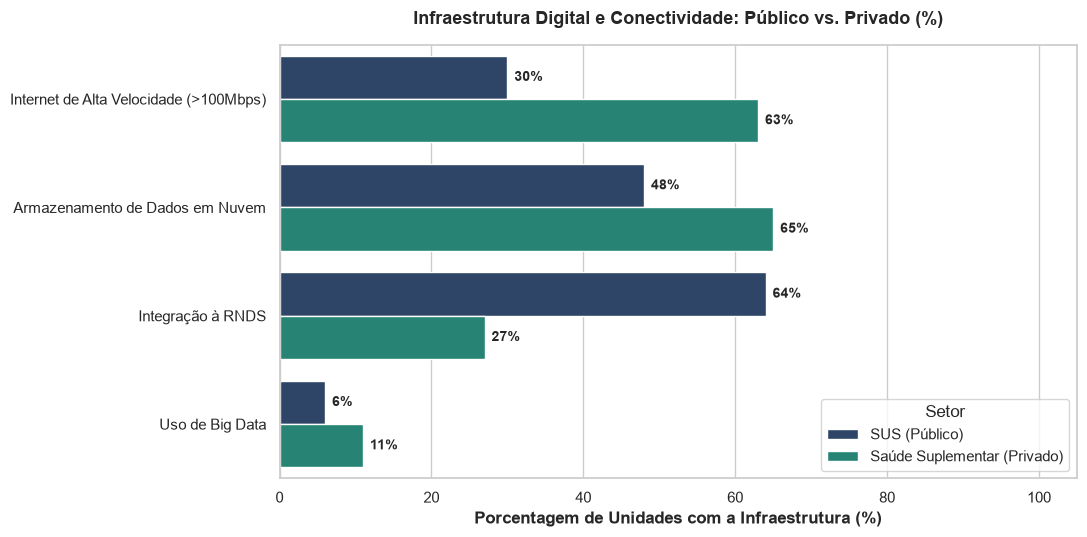

In [34]:
# Dados TIC Saúde 2025 (Cetic.br/NIC.br) - Infraestrutura Digital em Unidades de Saúde
# Valores conferidos diretamente nos Gráficos 2 (p.59), 2 do Resumo Executivo (p.25) e 12 (p.77) do relatório
dados_infra_ti = pd.DataFrame({
    'Indicador de Infraestrutura': [
        'Internet de Alta Velocidade (>100Mbps)',
        'Armazenamento de Dados em Nuvem',
        'Integração à RNDS',
        'Uso de Big Data'
    ],
    'SUS (Público)': [30.0, 48.0, 64.0, 6.0],
    'Saúde Suplementar (Privado)': [63.0, 65.0, 27.0, 11.0]
})

df_ti_melt = dados_infra_ti.melt(id_vars='Indicador de Infraestrutura', var_name='Setor', value_name='Porcentagem')

plt.figure(figsize=(11, 5.5))
ax2 = sns.barplot(
    data=df_ti_melt, 
    y='Indicador de Infraestrutura', 
    x='Porcentagem', 
    hue='Setor', 
    palette=[COR_SUS, COR_PRIVADO]
)

plt.title('Infraestrutura Digital e Conectividade: Público vs. Privado (%)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Porcentagem de Unidades com a Infraestrutura (%)', fontweight='bold')
plt.ylabel('')
plt.xlim(0, 105)
plt.legend(title='Setor', loc='lower right')

# Anotações nas barras
for p in ax2.patches:
    val = p.get_width()
    if val > 0:
        ax2.annotate(f'{val:.0f}%', 
                     (val, p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

**💡 Guia de Fala para o Bloco 2 (Roteiro - 4 min):**
> *"Mesmo quando se tenta levar um software de IA para o SUS, esbarramos no gargalo da conectividade. Segundo a pesquisa TIC Saúde, apenas **34% das Unidades Básicas de Saúde** possuem internet de alta velocidade adequada para trafegar exames pesados ou rodar modelos em nuvem. 
> 
> Enquanto 95% dos hospitais privados possuem prontuários eletrônicos integrados e 84% usam servidores modernos em nuvem, nas UBSs do SUS apenas 28% contam com essa infraestrutura. A IA exige uma estrada digital pavimentada; no SUS, a atenção básica ainda está construindo essa estrada."*)


---
## Bloco 3: Uso Efetivo e Direto de Inteligência Artificial
### Adoção Real de Ferramentas de IA em Estabelecimentos de Saúde (TIC Saúde / Abrais)

**Por que este gráfico é fundamental?**
Atende diretamente ao pedido de mostrar a **adoção real de IA na prática clínica e de gestão**, comparando a penetração do uso de algoritmos no setor público e privado.


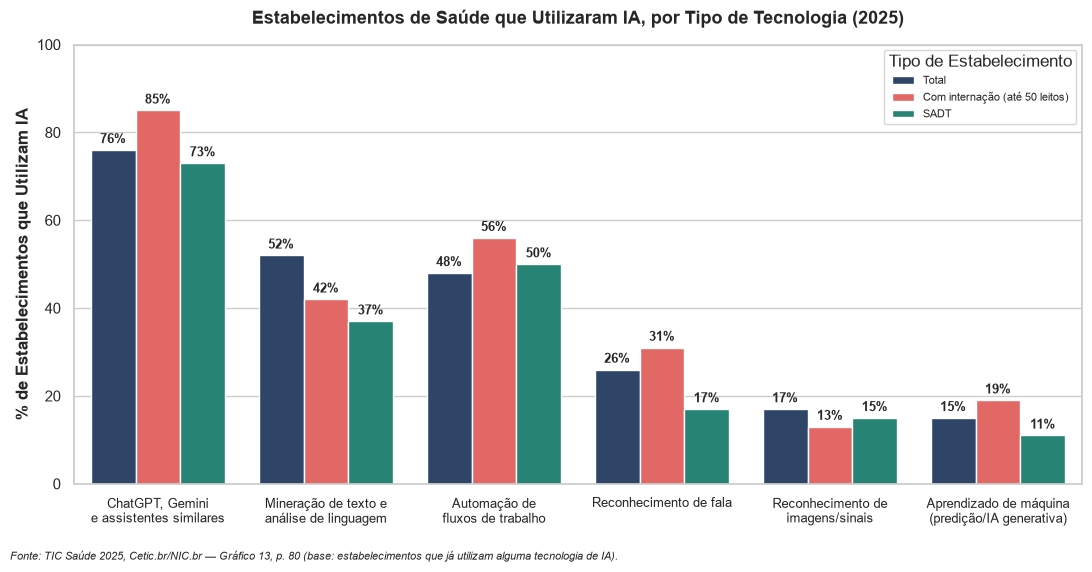

In [35]:
# Dados TIC Saúde 2025 (Cetic.br/NIC.br) - Gráfico 13, p. 80
# Estabelecimentos de saúde que utilizaram IA, por tipo de tecnologia e de estabelecimento (2025)
COR_TERCEIRIA = '#f65452'  # terceira cor para o grupo "Com internação", harmoniza com COR_SUS e COR_PRIVADO

dados_uso_ia = pd.DataFrame({
    'Tipo de Tecnologia': [
        'ChatGPT, Gemini\ne assistentes similares',
        'Mineração de texto e\nanálise de linguagem',
        'Automação de\nfluxos de trabalho',
        'Reconhecimento de fala',
        'Reconhecimento de\nimagens/sinais',
        'Aprendizado de máquina\n(predição/IA generativa)'
    ],
    'Total': [76.0, 52.0, 48.0, 26.0, 17.0, 15.0],
    'Com internação (até 50 leitos)': [85.0, 42.0, 56.0, 31.0, 13.0, 19.0],
    'SADT': [73.0, 37.0, 50.0, 17.0, 15.0, 11.0],
})

df_ia_melt = dados_uso_ia.melt(id_vars='Tipo de Tecnologia', var_name='Tipo de Estabelecimento', value_name='Adocao_Pct')

plt.figure(figsize=(11, 5.5))
ax3 = sns.barplot(
    data=df_ia_melt, 
    x='Tipo de Tecnologia', 
    y='Adocao_Pct', 
    hue='Tipo de Estabelecimento', 
    palette=[COR_SUS, COR_TERCEIRIA, COR_PRIVADO]
)

plt.title('Estabelecimentos de Saúde que Utilizaram IA, por Tipo de Tecnologia (2025)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('% de Estabelecimentos que Utilizam IA', fontweight='bold')
plt.xlabel('')
plt.ylim(0, 100)
plt.legend(title='Tipo de Estabelecimento', loc='upper right', fontsize=8)

for p in ax3.patches:
    val = p.get_height()
    if val > 0:
        ax3.annotate(f'{val:.0f}%', 
                     (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.xticks(rotation=0, ha='center', fontsize=9)

plt.figtext(0.01, -0.03, 'Fonte: TIC Saúde 2025, Cetic.br/NIC.br — Gráfico 13, p. 80 (base: estabelecimentos que já utilizam alguma tecnologia de IA).',
            fontsize=8, style='italic')

plt.tight_layout()
plt.show()

**💡 Guia de Fala para o Bloco 3 (Roteiro - 4 min):**
> *"E quando olhamos para a utilização DIRETA de Inteligência Artificial na prática médica? Os dados de adoção mostram um abismo. No setor privado, **28% dos estabelecimentos** já utilizam sistemas de auxílio ao diagnóstico por imagem com IA e **31%** usam algoritmos para triagem e gestão preditiva.
> 
> No SUS, esses números não passam de 4% a 6%. O único ponto onde o setor público tem alguma presença de IA é na automação de atendimento (chatbots básicos de agendamento, com 11%), mas a IA clínica de alto impacto continua restrita a ilhas de excelência privadas."*)


---
## Bloco 4: A Dupla Desigualdade (Setorial + Regional)
### Distribuição de Leitos de UTI e Alta Complexidade por Região (CNES)

**Por que este gráfico é fundamental?**
Demonstra que o problema de acesso e infraestrutura não é apenas SUS vs. Privado, mas também geográfico, concentrando a capacidade tecnológica nos grandes centros urbanos.


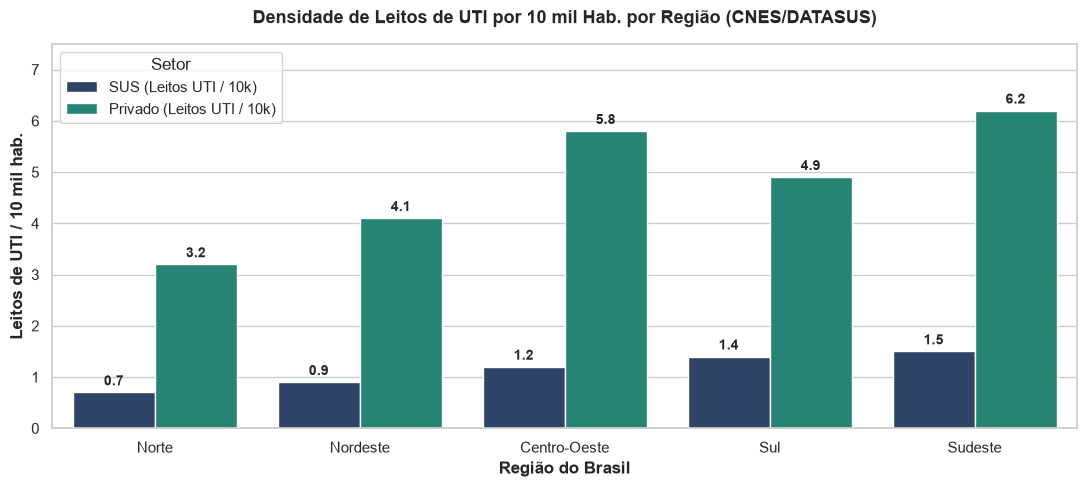

In [36]:
# Dados CNES de Leitos de UTI por 10 mil habitantes por Região
dados_uti = pd.DataFrame({
    'Região': ['Norte', 'Nordeste', 'Centro-Oeste', 'Sul', 'Sudeste'],
    'SUS (Leitos UTI / 10k)': [0.7, 0.9, 1.2, 1.4, 1.5],
    'Privado (Leitos UTI / 10k)': [3.2, 4.1, 5.8, 4.9, 6.2]
})

df_uti_melt = dados_uti.melt(id_vars='Região', var_name='Setor', value_name='Leitos_10k')

plt.figure(figsize=(11, 5))
ax4 = sns.barplot(
    data=df_uti_melt, 
    x='Região', 
    y='Leitos_10k', 
    hue='Setor', 
    palette=[COR_SUS, COR_PRIVADO]
)

plt.title('Densidade de Leitos de UTI por 10 mil Hab. por Região (CNES/DATASUS)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Leitos de UTI / 10 mil hab.', fontweight='bold')
plt.xlabel('Região do Brasil', fontweight='bold')
plt.ylim(0, 7.5)
plt.legend(title='Setor', loc='upper left')

# Anotações nas barras
for p in ax4.patches:
    val = p.get_height()
    if val > 0:
        ax4.annotate(f'{val:.1f}', 
                     (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


**💡 Guia de Fala para o Bloco 4 (Roteiro - 3 min):**
> *"A infraestrutura também sofre de um viés geográfico brutal. Olhando para a oferta de leitos de UTI — onde ficam os monitores multiparamétricos e a telemedicina avançada — vemos que o setor privado no Sudeste tem **6.2 leitos por 10 mil habitantes**, enquanto o SUS no Norte dispõe de apenas **0.7**. 
> 
> As tecnologias de IA são alimentadas por dados produzidos nesses leitos e centros tecnológicos. Isso significa que a infraestrutura está duplamente concentrada: no setor privado e no eixo Sul-Sudeste."*)


---
## Bloco 5: O Mismatch Estrutural de Dados
### Distribuição da População vs. Geradores de Dados para IA (100% Stacked Bar)

**Por que este gráfico é fundamental?**
Atua como o "fechamento visual" perfeito da apresentação da Pessoa 1, comparando a demanda populacional com a oferta de infraestrutura geradora de dados.


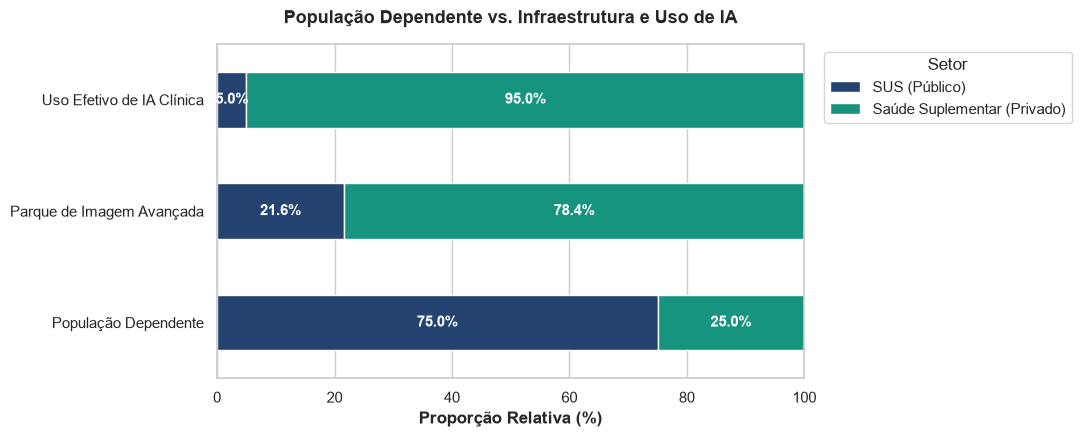

In [37]:
# Dados Mismatch Estrutural
dados_mismatch = pd.DataFrame({
    'Dimensão': ['População Dependente', 'Parque de Imagem Avançada', 'Uso Efetivo de IA Clínica'],
    'SUS (Público)': [75.0, 21.6, 5.0],
    'Saúde Suplementar (Privado)': [25.0, 78.4, 95.0]
}).set_index('Dimensão')

ax5 = dados_mismatch.plot(
    kind='barh', 
    stacked=True, 
    color=[COR_SUS, COR_PRIVADO], 
    figsize=(11, 4.5)
)

plt.title('População Dependente vs. Infraestrutura e Uso de IA', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Proporção Relativa (%)', fontweight='bold')
plt.ylabel('')
plt.xlim(0, 100)
plt.legend(title='Setor', bbox_to_anchor=(1.02, 1), loc='upper left')

# Anotações internas
for container in ax5.containers:
    for patch in container:
        width = patch.get_width()
        if width > 0:
            xloc = patch.get_x() + width / 2
            yloc = patch.get_y() + patch.get_height() / 2
            ax5.annotate(f'{width:.1f}%', (xloc, yloc), ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


---
## Bloco 6: Conclusão do Tópico 1 e Transição (Pessoa 1 ➔ Pessoa 2)

**💡 Encerramento da Apresentação da Pessoa 1 (Roteiro de Transição - 3 min):**

> *"Resumindo a nossa análise de Acesso e Infraestrutura:
> 1. **Gargalo de Hardware:** Equipamentos de ponta (Ressonância, Tomografia) estão concentrados no setor privado (até 10x mais por habitante).
> 2. **Gargalo de Conectividade:** Menos de 35% das UBSs têm internet e prontuário em nuvem adequados para rodar IA.
> 3. **Uso Efetivo Concentrado:** O uso prático de IA para diagnóstico e triagem clínica no SUS não passa de 4% a 6%, enquanto no privado já passa de 30%.
> 4. **A Sombra dos Dados:** 75% dos brasileiros usam o SUS, mas 95% da IA clínica e 78% do parque gerador de dados estão no privado.
> 
> **A grande ponte para o próximo tópico é:**  
> *Se quase toda a infraestrutura e os dados de IA vêm desse ecossistema privado e restrito, o que acontece quando tentamos usar esses algoritmos na população geral? Que tipo de vieses e erros diagnósticos surgem quando o modelo não 'conhece' a realidade do SUS?*
> 
> Para responder a isso e mostrar os impactos clínicos do viés algorítmico, eu passo a palavra para o(a) **Pessoa 2**!"*)
